## Calidad de sueño y estilo de vida
En este conjunto de datos sacado de Kaggle cuenta con datos de la calidad de sueño de distintas personas, las columnas que se encuentran son las siguientes:
* Person ID: Un identificador para cada persona
* Gener: El género de la persona 
* Age: La edad de las personas en años
* Occupation: - La ocupación o profesión 
* Sleep Duration (hours) - El número de horas que la persona duerme por día
* Quality Sleep (scale: 1-10) - Una calificación subjetiva de la calidad del sueño
* Physical Activity Level (minutes/day) - El número de minutos que la persona hace actividad física diariamente
* Stress Level (scale: 1-10) - Una calificacoón subjetiva del nivel de estres experimentado por la persona
* BMI Category - La categoría de Índice de Masa Corporal
* Blood Pressure (systolic/diastolic) - La presión arterial de la persona, indicado como presión sistólica sobre presión diastólica
* Heart Rate (bpm) - La frecuencia cardíaca en reposo en latidos por minuto
* Dialy Steps - El número de pasos que la persona hace al día
* Sleep Disorder - La presencia o ausensica de transtornos del sueño en la persona.

### Preguntas que buscamos responder con este conjunto
Las preguntas que buscaremos responder con este conjunto de datos son las siguientes:

* ¿Quiénes tienen peor calidad del sueño, hombres o mujeres? 
* ¿Existe una relación entre la calidad del sueño de las personas y su profesión?
* ¿La actividad física afecta al sueño?
* ¿Qué profesión presenta la peor calidad de sueño?
* ¿Cuál profesión tienen a las personas con el mayor nivel de estrés y el mayor índice de masa corporal?
* ¿En qué rango de edades se encuentran la mayor cantidad de trastornos del sueño?
* La cantidad de pasos al día, ¿afecta la calidad del sueño? ¿al índice de masa corporal?

In [2]:
import pandas as pd

data = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
data.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
# informacion de la data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [4]:
data.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
# Promedio de la calidad del sueño por género
data.groupby('Gender')["Quality of Sleep"].mean()

Gender
Female    7.664865
Male      6.968254
Name: Quality of Sleep, dtype: float64

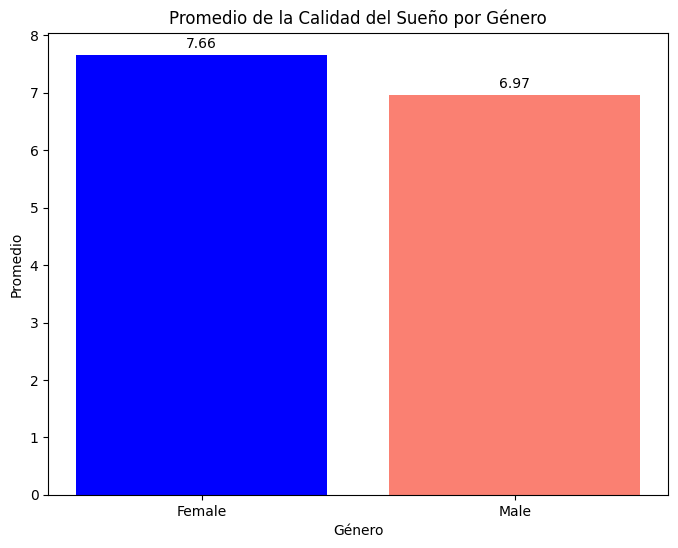

In [9]:
import matplotlib.pyplot as plt

promedio_sueño = data.groupby('Gender')["Quality of Sleep"].mean()
fig, ax = plt.subplots(figsize=(8, 6))
barras = ax.bar(promedio_sueño.index, promedio_sueño.values, color=["blue", "salmon"])

plt.title("Promedio de la Calidad del Sueño por Género")
plt.xlabel("Género")
plt.ylabel("Promedio")
ax.bar_label(barras, fmt="%.2f", padding=3)

plt.show()

In [11]:
cantidad = data["Occupation"].value_counts()
cantidad

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64